In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp 4 Kryoskopie.xlsx", engine="openpyxl",
                   usecols="AQ,AR", skiprows=14, nrows=16)
df.columns = ["m_Salz/m_Wasser", "DeltaT_Sm"]
# Konvertiere sicherheitshalber alle Werte zu float und entferne NaNs
df = df.apply(pd.to_numeric, errors='coerce')  # wandelt nicht-numerische Einträge in NaN
df.dropna(inplace=True)  # entfernt alle Zeilen mit NaNs

# Jetzt Daten entnehmen
x = df["m_Salz/m_Wasser"].values
y = df["DeltaT_Sm"].values

# ===============================
# Daten extrahieren
# ===============================
x = df["m_Salz/m_Wasser"].values  # x-Achse: Massenverhältnis
y = df["DeltaT_Sm"].values        # y-Achse: Gefrierpunktserniedrigung

# ===============================
# Lineare Regression
# ===============================
def lin_func(x, a):
    return a * x  # Kein y-Achsenabschnitt, da durch Ursprung

popt, pcov = curve_fit(lin_func, x, y)
slope = popt[0]
slope_err = sqrt(pcov[0][0])

# Fit-Kurve für Plot
x_fit = np.linspace(min(x), max(x), 200)
y_fit = lin_func(x_fit, slope)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label='Messwerte')
plt.plot(x_fit, y_fit, '-', color='red', label=f'Fit: ΔT = {slope:.3f}·(m_Salz/m_Wasser)')

plt.xlabel("Massenverhältnis $m_{Salz}/m_{Wasser}$")
plt.ylabel("Gefrierpunktserniedrigung ΔT [K]")
plt.title("ΔT vs. Massenverhältnis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnis ausgeben
# ===============================
print(f"Fit-Steigung (Proportionalitätsfaktor): {slope:.4f} ± {slope_err:.4f} K·(g/g)^-1")

ValueError: `ydata` must not be empty!

In [7]:
print(df)

Empty DataFrame
Columns: [m_Salz/m_Wasser, DeltaT_Sm]
Index: []


Gefundene Sheets: ['Tabelle1', '15 Graphen + Gefrierpunkt', 'Tabelle4']


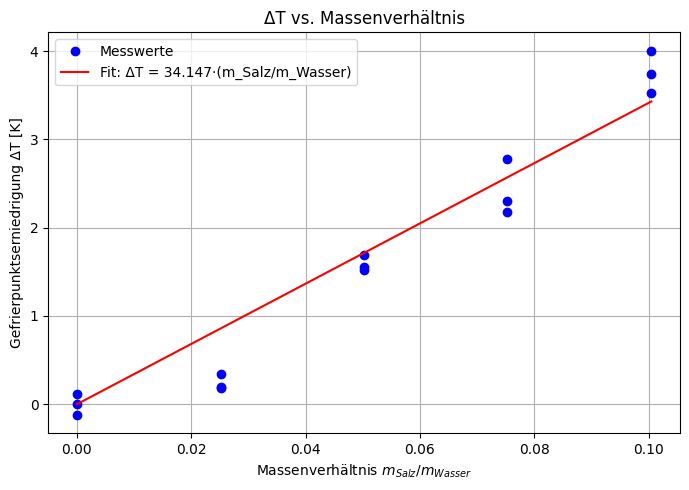

Fit-Steigung (Proportionalitätsfaktor): 34.1471 ± 1.5753 K·(g/g)^-1


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"

# Blattnamen prüfen
xls = pd.ExcelFile(excel_file, engine="openpyxl")
print("Gefundene Sheets:", xls.sheet_names)

# Wähle das Blatt mit den Messdaten (z. B. "Kryoskopie" oder "Sheet2")
sheet_name = xls.sheet_names[1]  # Blatt 2 (Index 1)

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AQ,AR",
                   skiprows=14,
                   nrows=16)

df.columns = ["m_Salz/m_Wasser", "DeltaT_Sm"]

# ===============================
# Bereinigen: NaNs entfernen
# ===============================
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

if df.empty:
    raise ValueError("Keine gültigen Daten gefunden. Bitte prüfe Sheet, Spalten oder Zeilen.")

# ===============================
# Daten extrahieren
# ===============================
x = df["m_Salz/m_Wasser"].values
y = df["DeltaT_Sm"].values

# ===============================
# Lineare Regression
# ===============================
def lin_func(x, a):
    return a * x  # Kein y-Achsenabschnitt

popt, pcov = curve_fit(lin_func, x, y)
slope = popt[0]
slope_err = sqrt(pcov[0, 0])

# Fit-Kurve erzeugen
x_fit = np.linspace(min(x), max(x), 300)
y_fit = lin_func(x_fit, slope)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit, '-', label=f'Fit: ΔT = {slope:.3f}·(m_Salz/m_Wasser)', color='red')

plt.xlabel("Massenverhältnis $m_{Salz}/m_{Wasser}$")
plt.ylabel("Gefrierpunktserniedrigung ΔT [K]")
plt.title("ΔT vs. Massenverhältnis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnis ausgeben
# ===============================
print(f"Fit-Steigung (Proportionalitätsfaktor): {slope:.4f} ± {slope_err:.4f} K·(g/g)^-1")

In [9]:
print(df)

    m_Salz/m_Wasser  DeltaT_Sm
0          0.000000   0.006667
1          0.000000   0.116667
2          0.000000  -0.123333
3          0.025284   0.186667
4          0.025284   0.346667
5          0.025284   0.196667
6          0.050239   1.516667
7          0.050239   1.686667
8          0.050239   1.556667
9          0.075160   2.776667
10         0.075160   2.176667
11         0.075160   2.306667
12         0.100444   4.006667
13         0.100444   3.746667
14         0.100444   3.526667


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"

# Blattnamen prüfen
xls = pd.ExcelFile(excel_file, engine="openpyxl")
print("Gefundene Sheets:", xls.sheet_names)

# Blatt 2 auswählen (Index 1)
sheet_name = xls.sheet_names[1]

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AQ,AR",
                   skiprows=14,
                   nrows=16)

df.columns = ["m_Salz/m_Wasser", "DeltaT_Sm"]

# ===============================
# NaNs bereinigen
# ===============================
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

if df.empty:
    raise ValueError("Keine gültigen Daten gefunden. Bitte prüfe das Tabellenblatt.")

# ===============================
# Daten extrahieren
# ===============================
x = df["m_Salz/m_Wasser"].values
y = df["DeltaT_Sm"].values

# ===============================
# Lineare Regression (ΔT = a·x)
# ===============================
def lin_func(x, a):
    return a * x

popt, pcov = curve_fit(lin_func, x, y)
slope = popt[0]
slope_err = sqrt(pcov[0, 0])

# ===============================
# Kryoskopie-Fit zur Bestimmung von M
# ===============================
def kryo_func(x, M):
    i = 2       # van-'t-Hoff-Faktor (z. B. NaCl → 2)
    Kf = 1.86   # kryoskopische Konstante von Wasser [K·kg/mol]
    return (Kf*i*m_Salz/(M*m_Wasser))

initial_guess = [100]  # Startwert für Molmasse
popt_M, pcov_M = curve_fit(kryo_func, x, y, p0=initial_guess)
M_fit = popt_M[0]
M_err = sqrt(pcov_M[0, 0])

# ===============================
# Fit-Kurven berechnen
# ===============================
x_fit = np.linspace(min(x), max(x), 300)
y_fit_linear = lin_func(x_fit, slope)
y_fit_kryo = kryo_func(x_fit, M_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit_linear, '-', color='red',
         label=f'Linear: ΔT = {slope:.3f}·x')
plt.plot(x_fit, y_fit_kryo, '--', color='green',
         label=f'Kryo-Fit: M ≈ {M_fit:.2f} ± {M_err:.2f} g/mol')

plt.xlabel("Massenverhältnis $m_{Salz}/m_{Wasser}$")
plt.ylabel("Gefrierpunktserniedrigung ΔT [K]")
plt.title("ΔT vs. Massenverhältnis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse ausgeben
# ===============================
print(f"Lineare Fit-Steigung: {slope:.4f} ± {slope_err:.4f} K·(g/g)^-1")
print(f"Molmasse M (aus Kryo-Fit): {M_fit:.2f} ± {M_err:.2f} g/mol")

Gefundene Sheets: ['Tabelle1', '15 Graphen + Gefrierpunkt', 'Tabelle4']


NameError: name 'm_Salz' is not defined

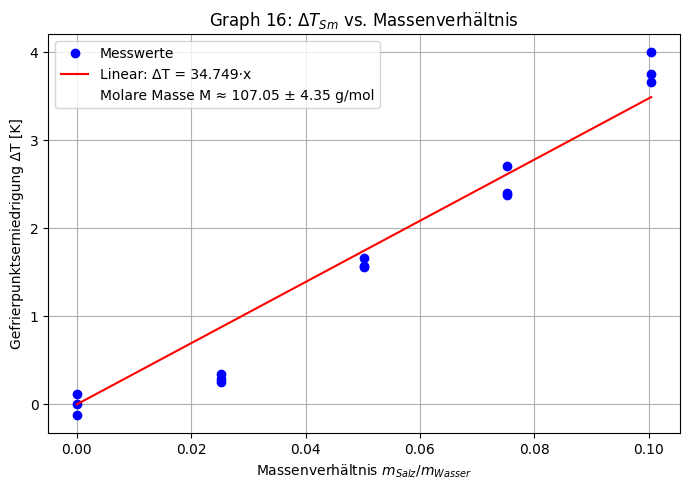

Lineare Fit-Steigung: 34.7492 ± 1.4115 K·(g/g)^-1
Molmasse M (aus Kryo-Fit): 107.05 ± 4.35 g/mol


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"

# Blattnamen prüfen und Blatt 2 auswählen
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]  # 2. Blatt (Index 1)

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AQ,AR",
                   skiprows=14,
                   nrows=20)

df.columns = ["m_Salz/m_Wasser", "DeltaT_Sm"]

# ===============================
# NaNs bereinigen
# ===============================
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

if df.empty:
    raise ValueError("Keine gültigen Daten gefunden. Bitte prüfe das Tabellenblatt.")

# ===============================
# Daten extrahieren
# ===============================
x = df["m_Salz/m_Wasser"].values  # Massenverhältnis
y = df["DeltaT_Sm"].values        # Gefrierpunktserniedrigung

# ===============================
# Lineare Regression (ΔT = a·x)
# ===============================
def lin_func(x, a):
    return a * x

popt, pcov = curve_fit(lin_func, x, y)
slope = popt[0]
slope_err = sqrt(pcov[0, 0])

# ===============================
# Kryoskopie-Funktion: ΔT = (i·Kf / M) · (m_Salz / m_Wasser)
# ===============================
def kryo_func(x, M):
    i = 2      # van-'t-Hoff-Faktor (z. B. NaCl → 2)
    Kf = 1860  # Kryoskopische Konstante [K·kg/mol]
    return (i * Kf / M) * x

# Fit zur Molmassen-Bestimmung
initial_guess = [100]
popt_M, pcov_M = curve_fit(kryo_func, x, y, p0=initial_guess)
M_fit = popt_M[0]
M_err = sqrt(pcov_M[0, 0])

# ===============================
# Fit-Kurven berechnen
# ===============================
x_fit = np.linspace(min(x), max(x), 300)
y_fit_linear = lin_func(x_fit, slope)
y_fit_kryo = kryo_func(x_fit, M_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit_linear, '-', color='red',
         label=f'Linear: ΔT = {slope:.3f}·x')
plt.plot([], [], ' ', label=f'Molare Masse M ≈ {M_fit:.2f} ± {M_err:.2f} g/mol')

plt.xlabel("Massenverhältnis $m_{Salz}/m_{Wasser}$")
plt.ylabel("Gefrierpunktserniedrigung ΔT [K]")
plt.title("Graph 16: $ΔT_{Sm}$ vs. Massenverhältnis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse ausgeben
# ===============================
print(f"Lineare Fit-Steigung: {slope:.4f} ± {slope_err:.4f} K·(g/g)^-1")
print(f"Molmasse M (aus Kryo-Fit): {M_fit:.2f} ± {M_err:.2f} g/mol")

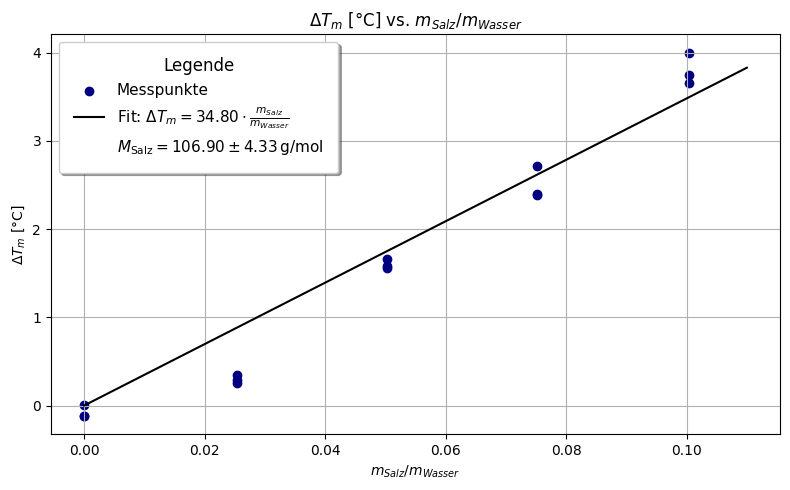

NameError: name 'r2' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gegebene mSalz/mWasser Werte (alle Messungen, keine Mittelwerte)
x = np.array([
   0, 0, 0,
   0.0253, 0.0253, 0.0253,
   0.0502,  0.0502,  0.0502,
   0.0752, 0.0752, 0.0752,
   0.1004,   0.1004,   0.1004
])

# Korrigierte Gefrierpunkte (T_Lösung) in °C
T_korr = np.array([
   -0.01, 0.12, 0.12,
   -0.26, -0.35, -0.29,
   -1.58, -1.66, -1.56,
   -2.71, -2.40, -2.38,
   -4,  -3.75, -3.66
])

# ΔT_m = 0 - T_Lösung = -T_Lösung (da T_rein ≈ 0)
delta_Tm = -T_korr

# Lineare Fit-Funktion
def linear(x, a):
   return a * x

# Fit durchführen mit Fehlerberechnung
params, cov = curve_fit(linear, x, delta_Tm)
a_fit = params[0]
a_fit_err = np.sqrt(cov[0, 0])

# Molmasse berechnen + Fehler
Kf = 1.86  # für Wasser
M_salz = (2000 * Kf) / a_fit
M_salz_err = (2000 * Kf / a_fit**2) * a_fit_err

# Fit-Kurve berechnen
x_fit = np.linspace(0, 0.11, 100)
y_fit = linear(x_fit, a_fit)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, delta_Tm, color='navy', label='Messpunkte')
plt.plot(x_fit, y_fit, color='black',
        label=fr'Fit: $\Delta T_m = {a_fit:.2f} \cdot \frac{{m_{{Salz}}}}{{m_{{Wasser}}}}$')

# Legendeintrag für Molmasse mit Fehler
plt.plot([], [], ' ', label=fr'$M_{{\mathrm{{Salz}}}} = {M_salz:.2f} \pm {M_salz_err:.2f} \, \mathrm{{g/mol}}$')

plt.xlabel(r'$m_{Salz} / m_{Wasser}$')
plt.ylabel(r'$\Delta T_m$ [°C]')
plt.title(r'$\Delta T_m$ [°C] vs. $m_{Salz} / m_{Wasser}$')
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True,
          borderpad=1, ncol=1, title='Legende', title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

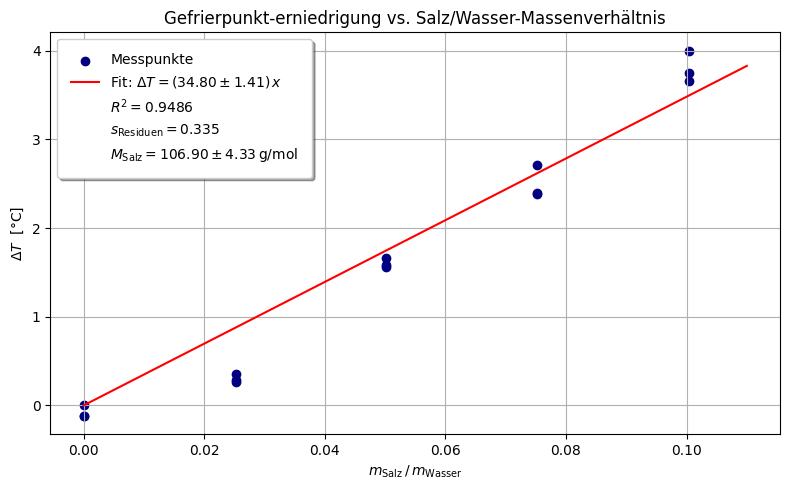

Fit-Parameter und Statistik
a                = 34.79770 ± 1.40893
R²               = 0.9486
Standardabweichung (RMSE) = 0.3355 °C

Molmasse Salz    = 106.90 ± 4.33 g/mol


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --------------------------------------------------
# Daten
# --------------------------------------------------
x = np.array([
   0, 0, 0,
   0.0253, 0.0253, 0.0253,
   0.0502, 0.0502, 0.0502,
   0.0752, 0.0752, 0.0752,
   0.1004, 0.1004, 0.1004
])

T_korr = np.array([
   -0.01, 0.12, 0.12,
   -0.26, -0.35, -0.29,
   -1.58, -1.66, -1.56,
   -2.71, -2.40, -2.38,
   -4.00, -3.75, -3.66
])

ΔT = -T_korr                    # Gefrierpunkt­erniedrigung

# --------------------------------------------------
# Linearer Fit ΔT = a · (m_Salz / m_Wasser)
# --------------------------------------------------
def linear(x, a):
    return a * x

popt, pcov = curve_fit(linear, x, ΔT)
a, = popt                         # Fit-Parameter
σ_a = np.sqrt(pcov[0, 0])         # 1-σ-Fehler von a

# --------------------------------------------------
# R² und Standardabweichung der Residuen (RMSE)
# --------------------------------------------------
ΔT_fit = linear(x, a)
residuen = ΔT - ΔT_fit

SS_res = np.sum(residuen**2)
SS_tot = np.sum((ΔT - np.mean(ΔT))**2)
R2 = 1 - SS_res / SS_tot

RMSE = np.sqrt(SS_res / (len(x) - 1))

# --------------------------------------------------
# Molmasse aus Gefrierpunkt­erniedrigung
# --------------------------------------------------
K_f = 1.86                        # Wasser
M_salz      = 2000 * K_f / a
σ_M_salz    = 2000 * K_f * σ_a / a**2

# --------------------------------------------------
# Plot
# --------------------------------------------------
x_plot = np.linspace(0, 0.11, 200)
plt.figure(figsize=(8, 5))

plt.scatter(x, ΔT, color='navy', label='Messpunkte')
plt.plot(x_plot, linear(x_plot, a), color='red',
         label=fr'Fit: $\Delta T = ({a:.2f}\pm{σ_a:.2f})\,x$')

# Legendeinträge für Ergebnisse
plt.plot([], [], ' ', label=fr'$R^2 = {R2:.4f}$')
plt.plot([], [], ' ', label=fr'$s_\mathrm{{Residuen}} = {RMSE:.3f}$')
plt.plot([], [], ' ',
         label=fr'$M_\mathrm{{Salz}} = {M_salz:.2f} \pm {σ_M_salz:.2f}\,\mathrm{{g/mol}}$')

plt.xlabel(r'$m_\mathrm{Salz}\, /\, m_\mathrm{Wasser}$')
plt.ylabel(r'$\Delta T$  [°C]')
plt.title(r'Gefrierpunkt­erniedrigung vs. Salz/Wasser-Massenverhältnis')
plt.legend(frameon=True, shadow=True, borderpad=1)
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Konsolenausgabe
# --------------------------------------------------
print("Fit-Parameter und Statistik")
print(f"a                = {a:.5f} ± {σ_a:.5f}")
print(f"R²               = {R2:.4f}")
print(f"Standardabweichung (RMSE) = {RMSE:.4f} °C")
print()
print(f"Molmasse Salz    = {M_salz:.2f} ± {σ_M_salz:.2f} g/mol")